# Name:Ritika lund
# CMS-ID:023-24-0262
# Section:H
# Github:
# Kaggle:


In [1]:
# impporting libraries
import pandas as pd
import numpy as np

# Part 1:Problem Definition & Dataset Verification

# Task 1:

In [2]:
df=pd.read_csv("clean_churn.csv")
print("shape of cleaned dataset :",df.shape)
print("\ndata types of cleaned dataset :\n",df.dtypes)
print("\nmissing values :\n",df.isnull().sum())
print("\nduplicated values before :",df.duplicated().sum())
df=df.drop_duplicates()
print("duplicated values after :",df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

shape of cleaned dataset : (7043, 20)

data types of cleaned dataset :
 gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

missing values :
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paper

# interpretation of task 1

The cleaned Telco Customer Churn dataset was successfully loaded and verified. After removing the duplicate rows, the dataset contains no duplicate records and no missing values. The column data types were also checked, confirming that the dataset is ready for the feature and target preparation stage.

# Task 2


we are predicting that whether the customers of teleco company will churn or not based on the their data .It matters alot to buisness as if the company is able to predict which customers are probably going to churn in future it can take actions to stop them from leaving.


# Part 2: Feature & Target Preparation 

# Task 3

In [3]:
print("checking if any identifier is still present in dataset :\n",df.columns.tolist())
y = df["Churn"].map({"No": 0, "Yes": 1})
# Define features
X = df.drop(columns=["Churn"])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

checking if any identifier is still present in dataset :
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
X shape: (7021, 19)
y shape: (7021,)

Target values:
Churn
0    5164
1    1857
Name: count, dtype: int64


# Task 3 interpretation

The Churn column was separated as the target variable y and encoded as 0 for No and 1 for Yes by using manual mapping. The remaining 19 columns were assigned to X as the input features, and no identifier column such as customerID remains in the dataset. The target contains 5,164 non-churned customers and 1,857 churned customers, showing that the classes are imbalanced.

# Task 4

In [4]:
categorical_cols=X.select_dtypes(include=["object","str"]).columns
print("Categorical columns: ")
print(categorical_cols)
X=pd.get_dummies(X,columns=categorical_cols,dtype=int)
print("New X shape after one-hot encoding: ",X.shape)


Categorical columns: 
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
New X shape after one-hot encoding:  (7021, 45)


# Task 4 interpretation
One-hot encoding was used to convert the categorical features into numeric form using pd.get_dummies(). This method creates a separate binary column for each category and avoids imposing an artificial numerical order on categories such as contract type, internet service, or payment method.

# Task 5 

In [5]:
print("Data types after encoding:")
print(X.dtypes)
print("\nMissing values in X: " ,X.isnull().sum().sum())

Data types after encoding:
SeniorCitizen                                int64
tenure                                       int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                                int64
gender_Male                                  int64
Partner_No                                   int64
Partner_Yes                                  int64
Dependents_No                                int64
Dependents_Yes                               int64
PhoneService_No                              int64
PhoneService_Yes                             int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
Onli

# Part 3: Train/Test split

# Task 6

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# Task 6 interpretation
The dataset was divided into 80% training data and 20% test data using train_test_split. Stratification was used because the Churn target is imbalanced, with more customers who did not churn than customers who churned. Using stratify=y helps preserve the original class proportions in both the training and test sets, making the evaluation more representative.

# Task 7

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5616, 45)
X_test: (1405, 45)
y_train: (5616,)
y_test: (1405,)


# Task 7 interpretation
The training set contains 5,616 customers with 45 features, while the test set contains 1,405 customers with the same 45 features. The corresponding target arrays contain 5,616 and 1,405 Churn labels respectively. The split accounts for all 7,021 customers.

# Part 4: Baseline Decision Tree

# Task 8

In [8]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
print("Training predictions :",y_train_pred)
print("Testing predictions :",y_test_pred)

Training predictions : [1 0 0 ... 1 0 0]
Testing predictions : [1 1 1 ... 0 0 0]


# Task 8 interpretation
An unrestricted Decision Tree classifier was trained using the training data with random_state=42. Predictions were generated for both the training and test sets. The training predictions show how the model classifies the data it learned from, while the test predictions represent its performance on unseen data. 

# Task 9

In [9]:
print("Tree depth:", model.get_depth())

Tree depth: 24


# Task 9 interpretation
The baseline Decision Tree has a maximum depth of 24. This indicates that the unrestricted tree has learned a relatively complex set of decision rules.

# Part 5: Model Evaluation

# Task 10

In [10]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
print("Test Accuracy :", accuracy)
print("Test Precision:", precision)
print("Test Recall   :", recall)
print("Test F1-score :", f1)

Test Accuracy : 0.7153024911032029
Test Precision: 0.4648241206030151
Test Recall   : 0.49731182795698925
Test F1-score : 0.4805194805194805


# Task 10 interpretation
The baseline Decision Tree achieved a test accuracy of 71.53%. However, its precision, recall, and F1-score were considerably lower, at 46.48%, 49.73%, and 48.05%, respectively. Since the Churn classes are imbalanced, accuracy alone is not sufficient to evaluate the model. The recall of 49.73% indicates that the model identifies approximately half of the customers who actually churn, so further investigation and model tuning are needed.

# Task 11

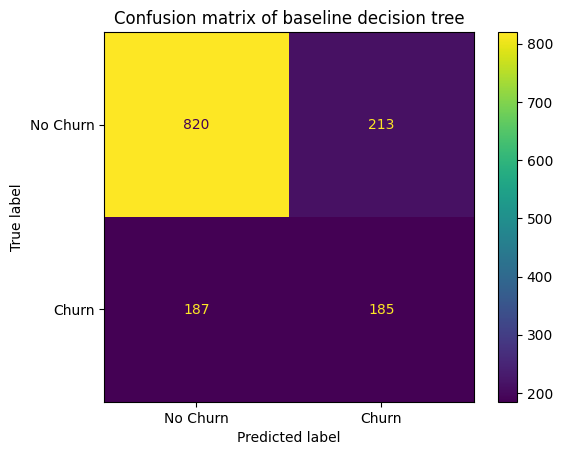

Confusion matrix :
[[820 213]
 [187 185]]


In [11]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_test_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Churn","Churn"])
disp.plot()
plt.title("Confusion matrix of baseline decision tree")
plt.show()
print("Confusion matrix :")
print(cm)

# Task 11 interpretaion
The confusion matrix shows that the model correctly classified 820 non-churning customers and 185 churning customers. It incorrectly predicted churn for 213 customers who did not actually churn, while 187 customers who actually churned were incorrectly predicted as non-churning. Therefore, the model successfully identified 185 out of 372 actual churners but missed 187 of them. This shows that the baseline model has difficulty identifying a substantial number of customers who are likely to churn.

# Task 12
Churn target is imbalanced as found in previous lab,that is why accuracy should not be used as the only evaluation metric. Recall is particularly important because it measures how many actual churners the model successfully identifies, while precision shows how reliable the model's churn predictions are. The F1-score is also useful because it balances precision and recall. Therefore, recall and F1-score should receive more attention than accuracy alone when evaluating this churn model.

# Part 6: Overfitting Investigation 

# Task 13

In [18]:
train_accuracy=accuracy_score(y_train,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Training accuracy : ",round((train_accuracy),3))
print("Testing accuracy : ",round(test_accuracy,3))
print("Accuracy Gap:", round((train_accuracy - test_accuracy),3))


Training accuracy :  0.998
Testing accuracy :  0.715
Accuracy Gap: 0.282


# Task 13 interpretaion
The baseline decision tree shows an accuracy gap of 0.28(28%) between the training and test accuracy.This is a large difference ,indicating that the model is performing very well on training data but poorly on testing data.Therefore the unrestriced tree shows evidence of overfitting. Its depth of 24 allows it to learn very detailed patterns in the training data, which may not generalize well to new customers.

# Task 14

In [24]:
depths=[2,3,4,5,6,8,10,None]
results=[]
for depth in depths:
    tree=DecisionTreeClassifier(max_depth=depth,random_state=42)
    tree.fit(X_train,y_train)
    test_pred=tree.predict(X_test)
    train_pred=tree.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    results.append({
        "max_depth": depth,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })
results_df=pd.DataFrame(results)
print(results_df)

   max_depth  train_accuracy  test_accuracy
0        2.0        0.764245       0.755872
1        3.0        0.792557       0.786477
2        4.0        0.798433       0.786477
3        5.0        0.802172       0.794306
4        6.0        0.813925       0.793594
5        8.0        0.841346       0.780783
6       10.0        0.879274       0.775801
7        NaN        0.997685       0.715302


# Task 14 interpretation
Decision Trees with different depths were trained and evaluated on both the training and test sets. Training accuracy generally increased as the maximum depth increased, reaching 99.77% for the unrestricted tree. However, test accuracy improved only up to a maximum depth of 5, where it reached 79.43%, and then decreased as the tree became deeper. This suggests that increasing tree complexity beyond this point causes the model to fit the training data more closely without improving its performance on unseen data.


# Task 15

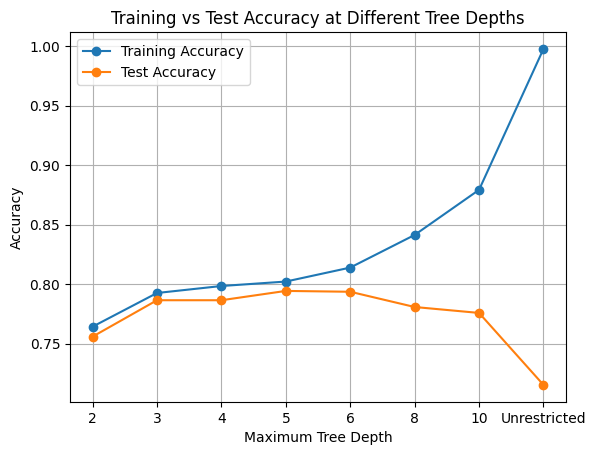

In [31]:
plot_df = results_df.copy()

plot_df["depth_label"] = plot_df["max_depth"].apply(
    lambda x: "Unrestricted" if pd.isna(x) else str(int(x))
)

plt.plot(
    plot_df["depth_label"],
    plot_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_df["depth_label"],
    plot_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)
plt.show()

# Task 15 interpretation
The training accuracy increases as the maximum tree depth increases, showing that deeper trees can fit the training data more closely. However, test accuracy improves only up to a maximum depth of 5, where it reaches 79.43%. After depth 5, test accuracy gradually decreases while training accuracy continues to increase. This pattern indicates increasing overfitting as the tree becomes deeper. The unrestricted tree shows the strongest overfitting, with very high training accuracy but substantially lower test accuracy.